# Generator analysis from grid data

Compare the empirical population map, its second-order generator approximation, and the full-channel spectral separation.


In [2]:
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PLOT_DIR = Path('docu/plots')
PLOT_DIR.mkdir(parents=True, exist_ok=True)


## Load grid


In [3]:
grid_nr = 6
N = 4
path = Path(f'data/grid/superoperator_N{N}_grid_{grid_nr}.npz')

data = np.load(path)
grid_h_over_J = data['h_over_J'] if 'h_over_J' in data.files else data['h']

print(f'Loaded: {path}')
print(f"Grid points: {len(data['h'])}")
print('alpha values:', np.unique(data['alpha']).tolist())
print('sigma values:', np.unique(data['sigma']).tolist())


Loaded: data/grid/superoperator_N4_grid_6.npz
Grid points: 200
alpha values: [0.02, 0.04000000000000001, 0.06000000000000001, 0.08000000000000002, 0.10000000000000002, 0.12000000000000002, 0.14, 0.16, 0.18000000000000002, 0.2, 0.22, 0.24, 0.26, 0.28, 0.30000000000000004, 0.32, 0.34, 0.36, 0.38, 0.4]
sigma values: [1.0]


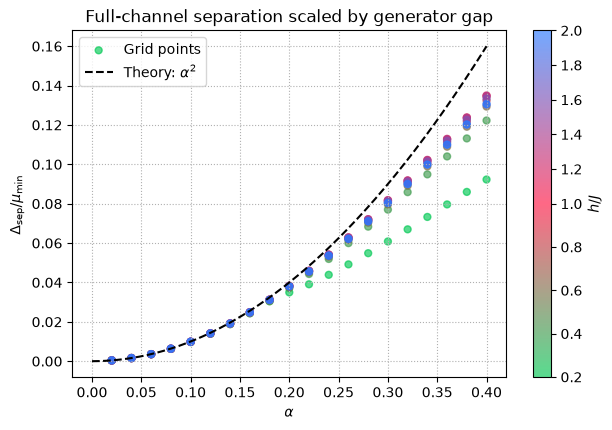

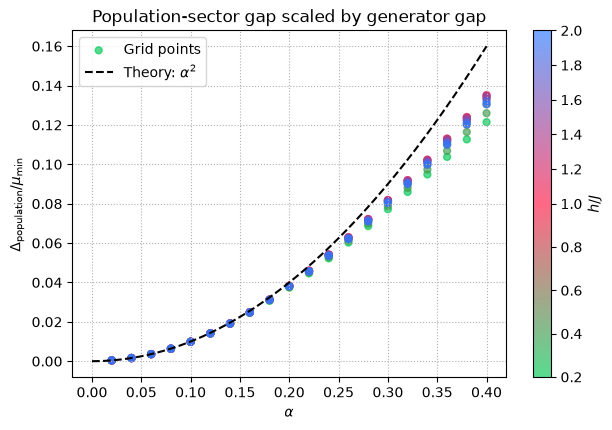

,h_over_J,alpha,generator_gap,Delta_sep,ratio
0,0.2,0.02,0.470355,0.000187,0.000398
1,0.2,0.04,0.470355,0.000746,0.001587
2,0.2,0.06,0.470355,0.001674,0.003559
3,0.2,0.08,0.470355,0.002962,0.006298
4,0.2,0.10,0.470355,0.004601,0.009782
...,...,...,...,...,...
195,2.0,0.32,0.363086,0.032666,0.089968
196,2.0,0.34,0.363086,0.036266,0.099883
197,2.0,0.36,0.363086,0.039944,0.110012
198,2.0,0.38,0.363086,0.043678,0.120296


In [19]:
import matplotlib.colors as mcolors

# The theory predicts Delta_sep / mu_min approximately equals alpha^2,
# where mu_min is the smallest positive generator decay rate.
required_keys = {'transition_generator', 'classical_populations', 'Delta_sep', 'alpha'}
missing_keys = required_keys.difference(data.files)
if missing_keys:
    raise KeyError(f'Missing required grid data: {sorted(missing_keys)}')

def generator_gap(generator):
    eigvals = np.linalg.eigvals(generator)
    stationary_index = np.argmin(np.abs(eigvals))
    nonstationary_eigvals = np.delete(eigvals, stationary_index)
    return -np.max(np.real(nonstationary_eigvals))

def population_gap(population_map):
    eigvals = np.linalg.eigvals(population_map)
    stationary_index = np.argmin(np.abs(eigvals - 1))
    nonstationary_eigvals = np.delete(eigvals, stationary_index)
    return 1 - np.max(np.abs(nonstationary_eigvals))

scaling_rows = []
for row_index, generator in enumerate(data['transition_generator']):
    alpha = float(data['alpha'][row_index])
    mu_min = generator_gap(generator)
    delta_sep = float(data['Delta_sep'][row_index])
    if np.isfinite(mu_min) and mu_min > 0 and np.isfinite(delta_sep):
        scaling_rows.append({
            'h_over_J': float(grid_h_over_J[row_index]),
            'alpha': alpha,
            'generator_gap': mu_min,
            'Delta_sep': delta_sep,
            'ratio': delta_sep / mu_min,
        })

scaling_data = pd.DataFrame(scaling_rows)
if scaling_data.empty:
    raise ValueError('No grid rows have a positive finite generator gap.')

fig, ax = plt.subplots(figsize=(7, 4.5))
h_norm = mcolors.TwoSlopeNorm(
    vmin=scaling_data['h_over_J'].min(), vcenter=1.0, vmax=scaling_data['h_over_J'].max()
)
h_cmap = mcolors.LinearSegmentedColormap.from_list(
    'h_over_J', ['#00c853', '#ff1744', '#2979ff']
)
points = ax.scatter(
    scaling_data['alpha'], scaling_data['ratio'], c=scaling_data['h_over_J'],
    cmap=h_cmap, norm=h_norm, s=25, alpha=0.65, label='Grid points'
)
colorbar = fig.colorbar(points, ax=ax)
colorbar.set_label(r'$h/J$')
alpha_theory = np.linspace(0, scaling_data['alpha'].max(), 200)
ax.plot(alpha_theory, alpha_theory**2, color='black', linestyle='--', label=r'Theory: $\alpha^2$')
ax.set_xlabel(r'$\alpha$')
ax.set_ylabel(r'$\Delta_{\mathrm{sep}} / \mu_{\min}$')
ax.set_title(r'Full-channel separation scaled by generator gap')
ax.grid(True, linestyle=':')
ax.legend()
plt.show()

population_scaling_rows = []
for row_index, (population_map, generator) in enumerate(
    zip(data['classical_populations'], data['transition_generator'])
):
    alpha = float(data['alpha'][row_index])
    mu_min = generator_gap(generator)
    delta_population = population_gap(population_map)
    if np.isfinite(mu_min) and mu_min > 0 and np.isfinite(delta_population):
        population_scaling_rows.append({
            'h_over_J': float(grid_h_over_J[row_index]),
            'alpha': alpha,
            'generator_gap': mu_min,
            'population_gap': delta_population,
            'ratio': delta_population / mu_min,
        })

population_scaling_data = pd.DataFrame(population_scaling_rows)
if population_scaling_data.empty:
    raise ValueError('No grid rows have a positive finite population-sector generator gap.')

fig, ax = plt.subplots(figsize=(7, 4.5))
population_points = ax.scatter(
    population_scaling_data['alpha'], population_scaling_data['ratio'],
    c=population_scaling_data['h_over_J'], cmap=h_cmap, norm=h_norm,
    s=25, alpha=0.65, label='Grid points'
)
colorbar = fig.colorbar(population_points, ax=ax)
colorbar.set_label(r'$h/J$')
ax.plot(alpha_theory, alpha_theory**2, color='black', linestyle='--', label=r'Theory: $\alpha^2$')
ax.set_xlabel(r'$\alpha$')
ax.set_ylabel(r'$\Delta_{\mathrm{population}} / \mu_{\min}$')
ax.set_title(r'Population-sector gap scaled by generator gap')
ax.grid(True, linestyle=':')
ax.legend()
plt.show()

scaling_data
